In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Loading the preprocessed data from 02_eda.ipynb

In [5]:

df = pd.read_csv('../data/processed/train_FD001_with_RUL_cleaned.csv')

sensor_cols = [col for col in df.columns if col.startswith('s_')]
print(f"Number of Active Sensors: {len(sensor_cols)}")
print(f"Active Sensors: {sensor_cols}")

print("Original Data Shape:", df.shape)

Number of Active Sensors: 14
Active Sensors: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
Original Data Shape: (20631, 17)


---
# Feature Engineering 1: Rolling Mean & Std
---

In [6]:
window_size = 5
df_feat = df.copy()

for sensor in sensor_cols:
    # 1. Rolling Mean (Moving Average)
    df_feat[f'{sensor}_mean'] = df_feat.groupby('unit_nr')[sensor]\
                                       .rolling(window=window_size, min_periods=1).mean()\
                                       .reset_index(level=0, drop=True)
    
    # 2. Rolling Standard Deviation (Volatility)
    df_feat[f'{sensor}_std'] = df_feat.groupby('unit_nr')[sensor]\
                                      .rolling(window=window_size, min_periods=1).std()\
                                      .reset_index(level=0, drop=True)


df_feat.head()

,unit_nr,time_cycles,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,...,s_14_mean,s_14_std,s_15_mean,s_15_std,s_17_mean,s_17_std,s_20_mean,s_20_std,s_21_mean,s_21_std
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,...,8138.620000,NaN,8.419500,NaN,392.000000,NaN,39.060000,NaN,23.419000,NaN
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,...,8135.055000,5.041671,8.425650,0.008697,392.000000,0.000000,39.030000,0.042426,23.421300,0.003253
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,...,8134.446667,3.717450,8.423033,0.007640,391.333333,1.154701,39.003333,0.055076,23.395600,0.044573
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,...,8134.292500,3.050906,8.409325,0.028117,391.500000,1.000000,38.972500,0.076322,23.390175,0.037977
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,...,8134.194000,2.651326,8.413340,0.025953,391.800000,1.095445,38.958000,0.073621,23.393020,0.033498


The standard deviation for a window of size 1 is NaN, so we fill NaNs with 0

In [7]:
df_feat = df_feat.fillna(0)

print("New Feature Shape:", df_feat.shape)
df_feat.head()

New Feature Shape: (20631, 45)


,unit_nr,time_cycles,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,...,s_14_mean,s_14_std,s_15_mean,s_15_std,s_17_mean,s_17_std,s_20_mean,s_20_std,s_21_mean,s_21_std
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,...,8138.620000,0.000000,8.419500,0.000000,392.000000,0.000000,39.060000,0.000000,23.419000,0.000000
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,...,8135.055000,5.041671,8.425650,0.008697,392.000000,0.000000,39.030000,0.042426,23.421300,0.003253
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,...,8134.446667,3.717450,8.423033,0.007640,391.333333,1.154701,39.003333,0.055076,23.395600,0.044573
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,...,8134.292500,3.050906,8.409325,0.028117,391.500000,1.000000,38.972500,0.076322,23.390175,0.037977
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,...,8134.194000,2.651326,8.413340,0.025953,391.800000,1.095445,38.958000,0.073621,23.393020,0.033498


### Piecewise Linear Target (The RUL Clip)
---
When an engine is brand new (e.g., 190 cycles left), it operates perfectly. The sensors for an engine with 190 cycles left look identical to an engine with 160 cycles left. If we force our model to learn the difference between 190 and 160, it will learn bad patterns because there is no difference in the physics yet.

The industry standard is to cap the RUL at 125. It is assumed that the engine is 100% healthy until it hits 125 cycles remaining, at which point the degradation finally becomes visible to the sensors.

In [8]:
MAX_RUL = 125

df_feat['RUL_clipped'] = df_feat['RUL'].clip(upper=MAX_RUL)


Visualizing the effect on Engine 1

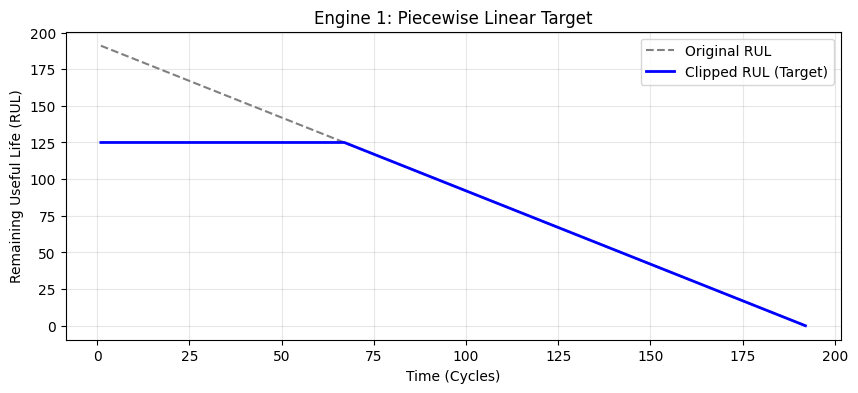

In [9]:
plt.figure(figsize=(10, 4))
engine_1 = df_feat[df_feat['unit_nr'] == 1]

plt.plot(engine_1['time_cycles'], engine_1['RUL'], label='Original RUL', linestyle='--', color='gray')
plt.plot(engine_1['time_cycles'], engine_1['RUL_clipped'], label='Clipped RUL (Target)', linewidth=2, color='blue')

plt.title('Engine 1: Piecewise Linear Target')
plt.xlabel('Time (Cycles)')
plt.ylabel('Remaining Useful Life (RUL)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()